# Análisis Exploratorio de Datos (EDA)

Exploraremos los datos limpios para comprender las relaciones entre las variables de supervivenia.

In [6]:
#importar librerias prerequeridas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#carga de datos
df = pd.read_csv('./data/titanic_clean.csv')

#visualizar cabecera del dataframe
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [7]:
#analisis
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
415,0,3,female,28.0,0,0,8.0500,S
494,0,3,male,21.0,0,0,8.0500,S
621,1,1,male,42.0,1,0,52.5542,S
438,0,1,male,64.0,1,4,263.0000,S


In [8]:
#analisis de survived
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

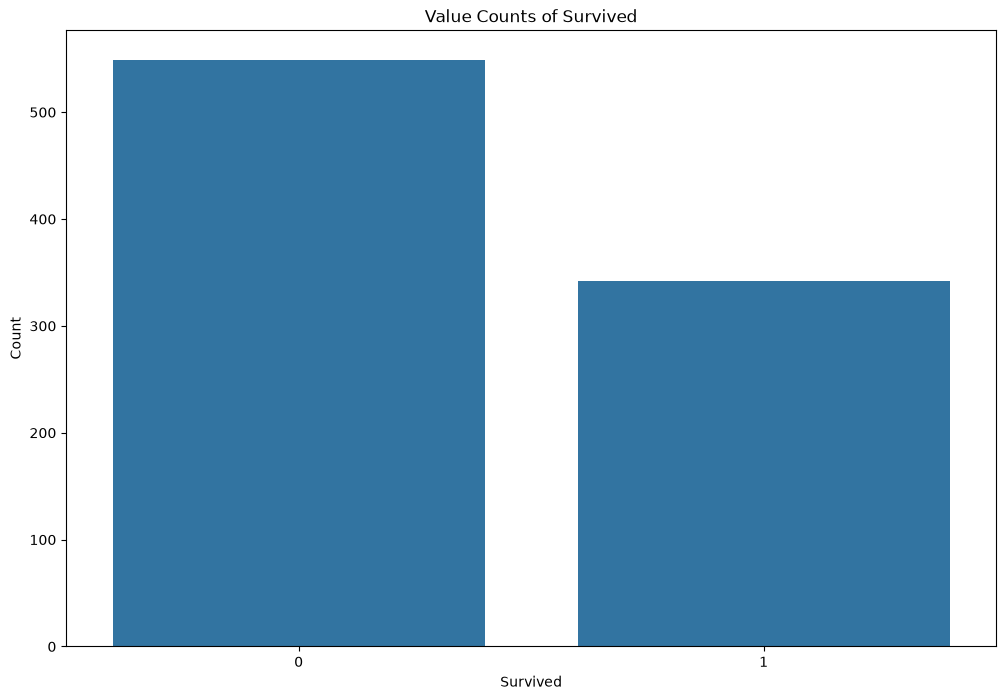

In [9]:
#grafica de barras
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

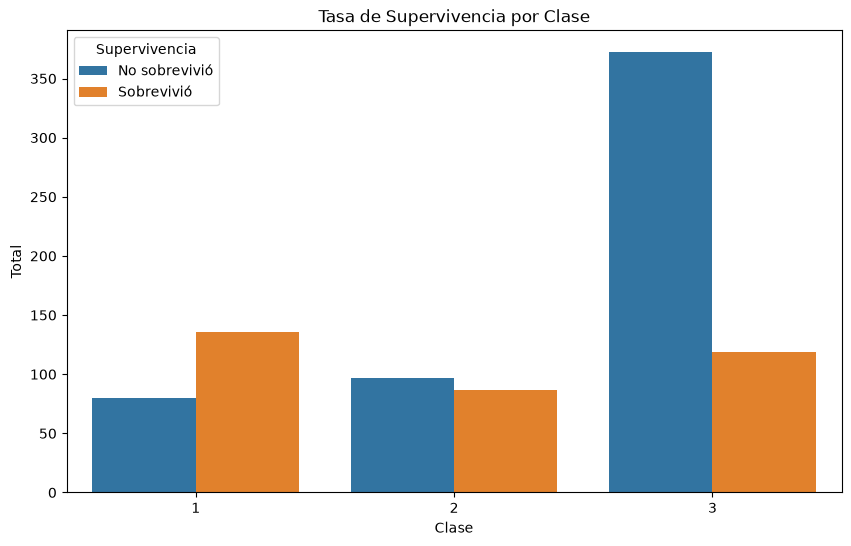

In [10]:
#grafica desde prompt
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title('Tasa de Supervivencia por Clase')
plt.xlabel('Clase')
plt.ylabel('Total')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sobrevivió']
)

plt.show()

# Supervivencia por Género

C:\Users\68323\AppData\Local\Temp\ipykernel_46904\1505585423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')


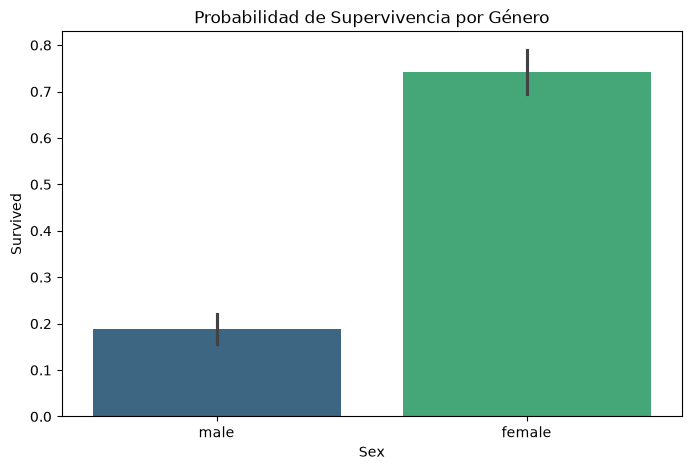

In [11]:
#sobrevivencia por genero
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Probabilidad de Supervivencia por Género')
plt.show()

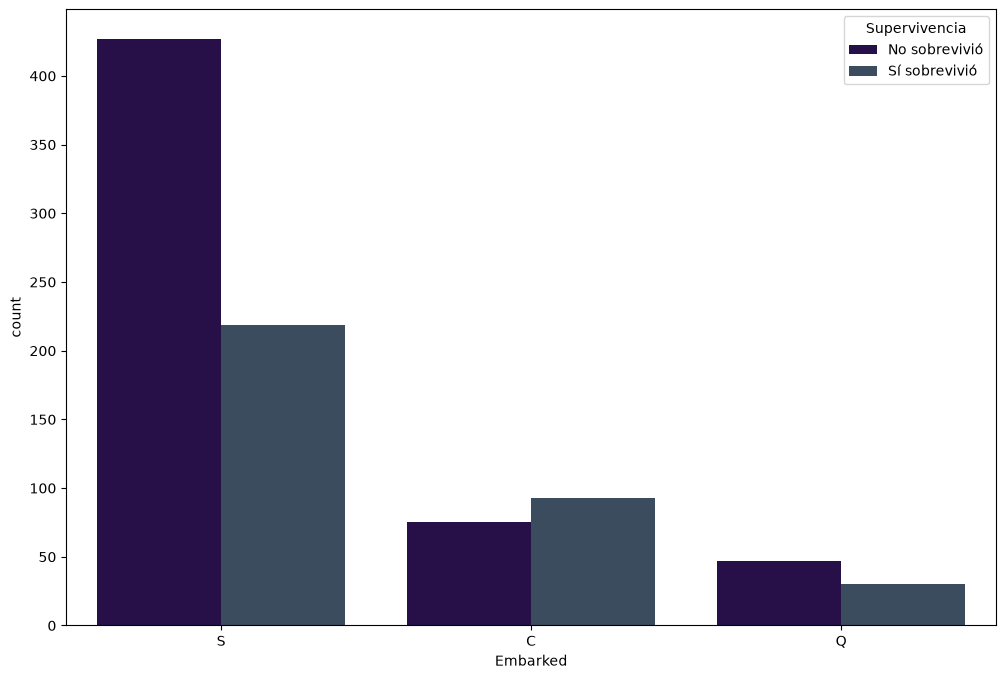

In [12]:
#supervivencia por clase y genero (codigo desde la leccion)
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

/var/folders/hm/f01qht_n4v7frppw014pwprc0000gn/T/ipykernel_91986/3078854192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')


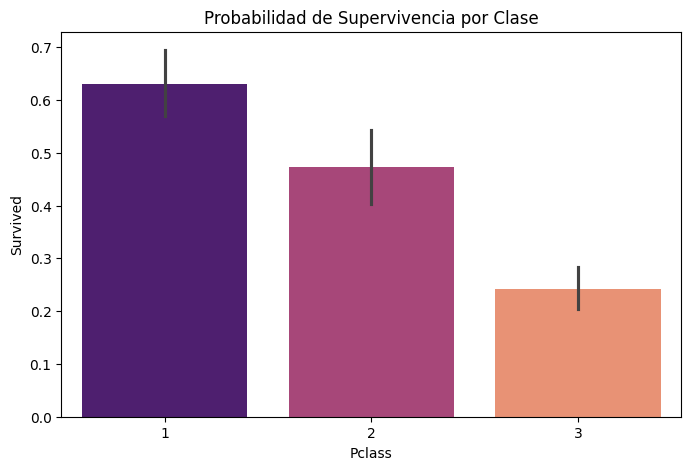

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')
plt.title('Probabilidad de Supervivencia por Clase')
plt.show()

# Distribución de Edades

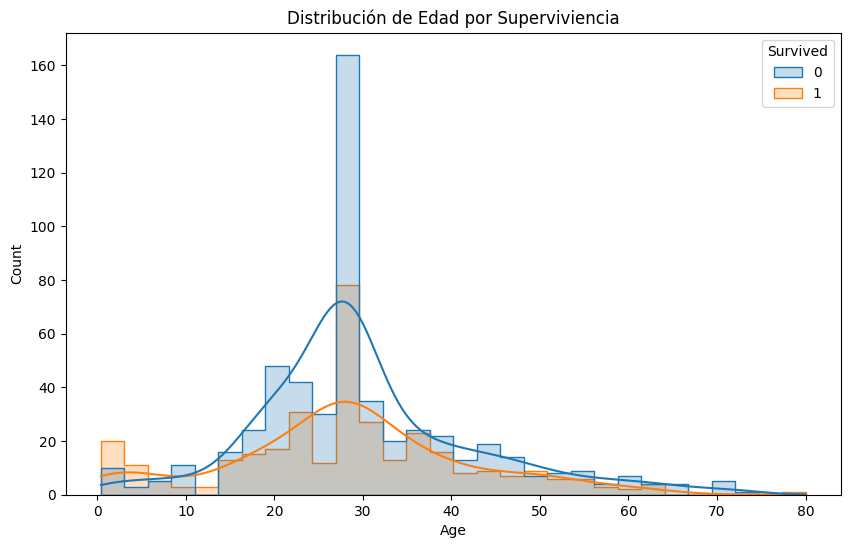

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue= 'Survived', kde=True, element='step')
plt.title('Distribución de Edad por Superviviencia')
plt.show()

In [12]:
df['Sex'] = df['Sex'].map({'male': 0, 'female':1})

df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb')

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Emb_C,Emb_Q,Emb_S
0,0,3,NaN,22.0,1,0,7.2500,False,False,True
1,1,1,NaN,38.0,1,0,71.2833,True,False,False
2,1,3,NaN,26.0,0,0,7.9250,False,False,True
3,1,1,NaN,35.0,1,0,53.1000,False,False,True
4,0,3,NaN,35.0,0,0,8.0500,False,False,True


In [13]:
df.to_csv('data/titanic_feature.csv', index= False)

print("Datos guardados en data/titanic_feature.csv")

Datos guardados en data/titanic_feature.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import LogisticRegression

df = pd.read_csv('data/titanic_feature.csv')

x = df.drop('Survived', axis=1)
y = df['Survived']



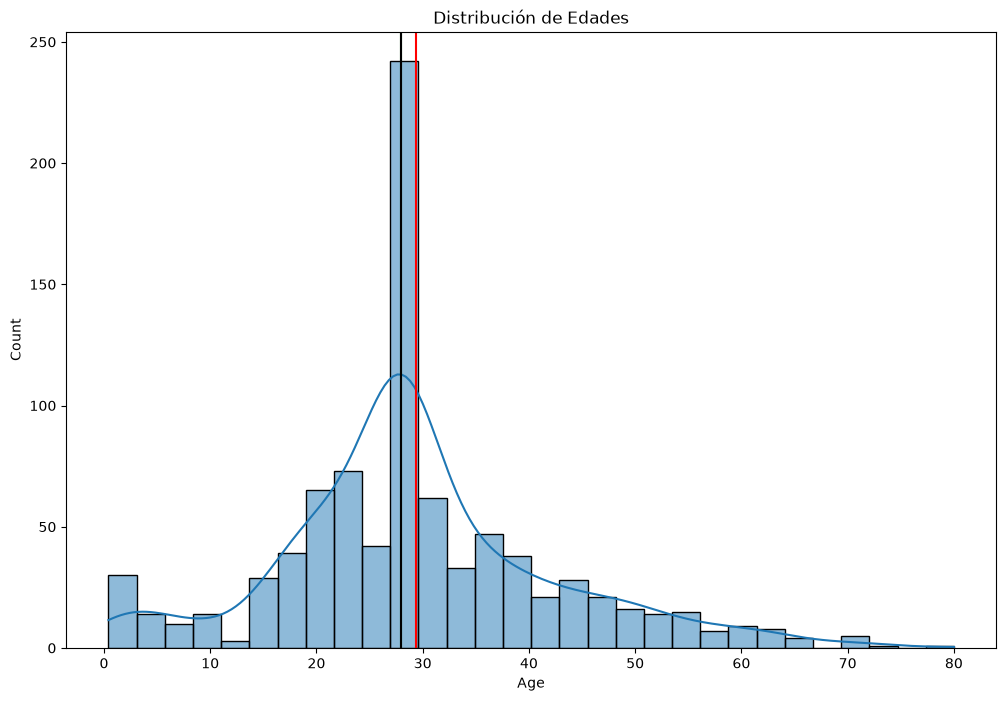

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


In [13]:
#distribucion por edades
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

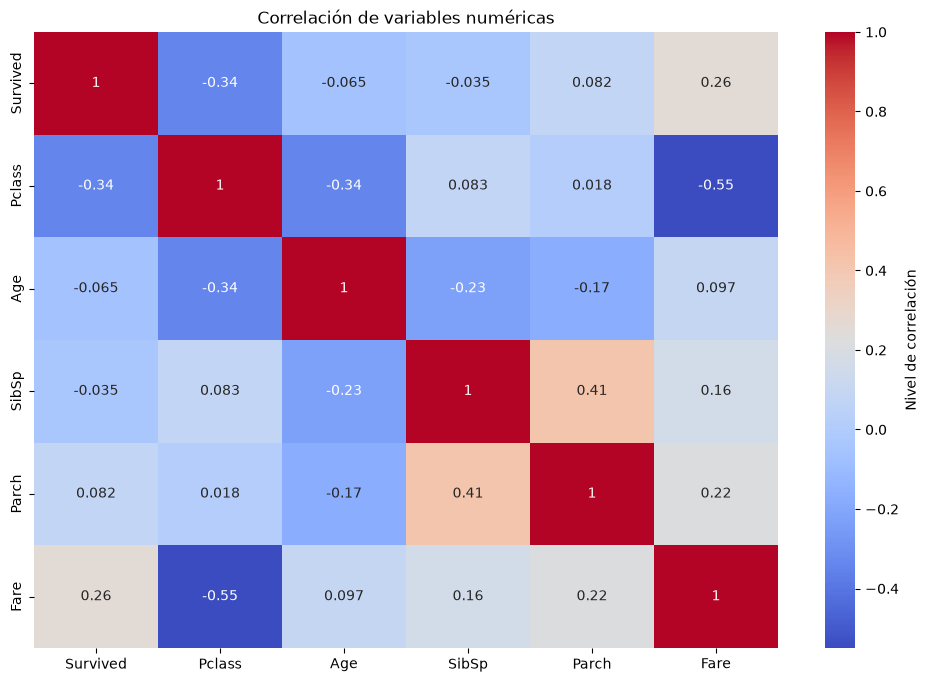

In [14]:
#matriz de correlacion
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

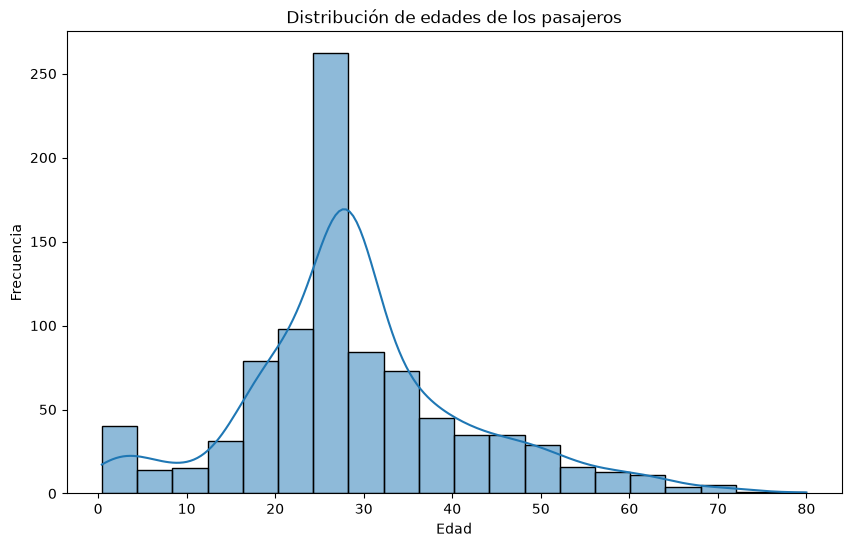

In [15]:
#Crea una gráfica que muestre la distribución de edades de los pasajeros.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Distribución de edades de los pasajeros')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

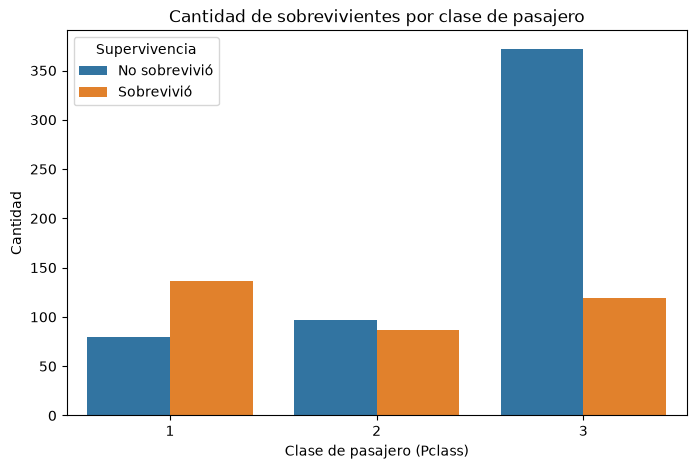

In [16]:
#Crea una gráfica que muestre la cantidad de sobrevivientes por clase de pasajero (Pclass).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Pclass',
    hue='Survived'
)

plt.title('Cantidad de sobrevivientes por clase de pasajero')
plt.xlabel('Clase de pasajero (Pclass)')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sobrevivió']
)

plt.show()

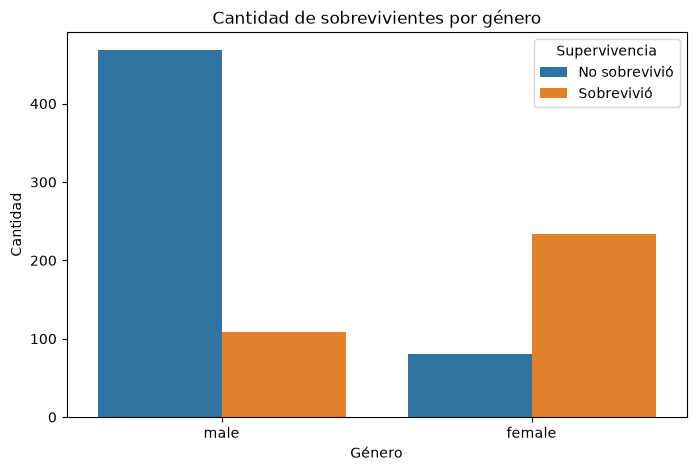

In [17]:
#Crea una gráfica que muestre la cantidad de sobrevivientes por género (Sex).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Sex',
    hue='Survived'
)

plt.title('Cantidad de sobrevivientes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sobrevivió']
)

plt.show()

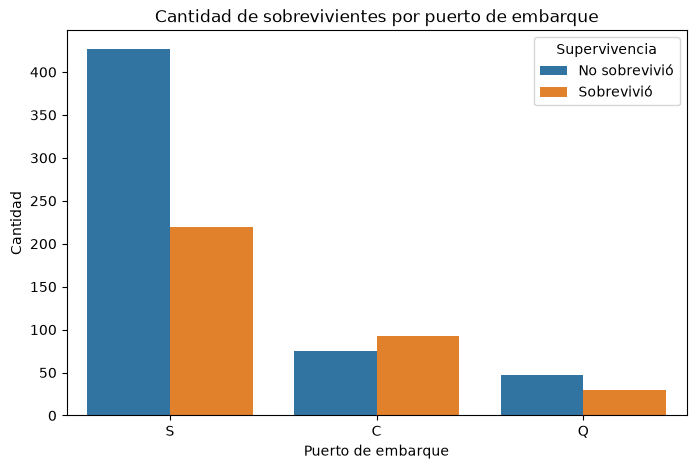

In [18]:
#Crea una gráfica que muestre la cantidad de sobrevivientes por puerto de embarque (Embarked).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Embarked',
    hue='Survived'
)

plt.title('Cantidad de sobrevivientes por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad')

plt.legend(
    title='Supervivencia',
    labels=['No sobrevivió', 'Sobrevivió']
)

plt.show()

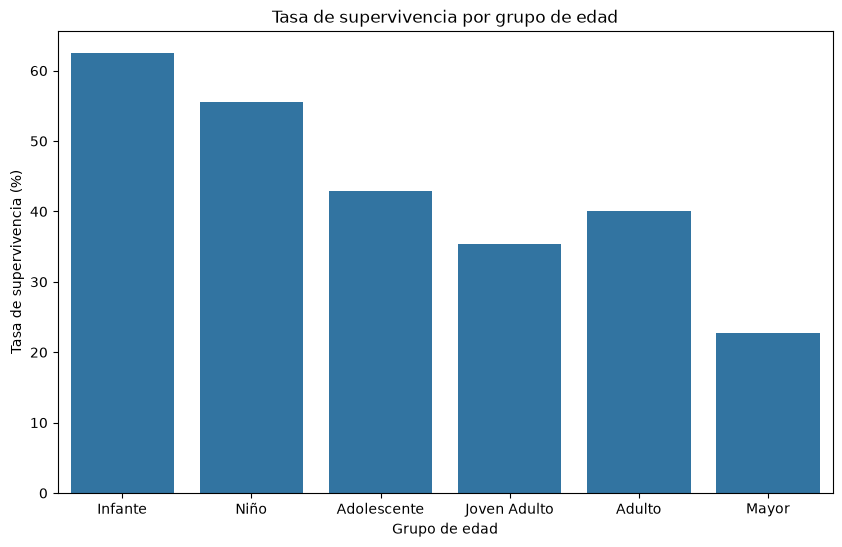

In [19]:
#Agrupa las edades en categorías (Infante, Niño, Adolescente, Joven Adulto, Adulto, Mayor) y crea una gráfica que muestre la tasa de supervivencia por grupo de edad.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear categorías de edad
bins = [0, 2, 12, 18, 35, 60, 100]
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']

df['GrupoEdad'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Calcular tasa de supervivencia por grupo
survival_rate = df.groupby('GrupoEdad')['Survived'].mean() * 100

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=survival_rate.index, y=survival_rate.values)

plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia (%)')

plt.show()

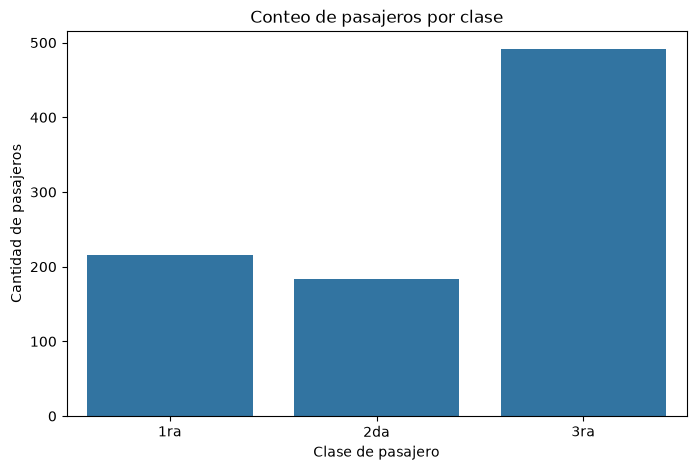

In [21]:
#Crea una gráfica que muestre el conteo de pasajeros en cada clase (Pclass).
import matplotlib.pyplot as plt
import seaborn as sns

# Cambiar etiquetas de clase
df['Clase'] = df['Pclass'].map({
    1: '1ra',
    2: '2da',
    3: '3ra'
})

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Clase',
    order=['1ra', '2da', '3ra']
)

plt.title('Conteo de pasajeros por clase')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad de pasajeros')

plt.show()

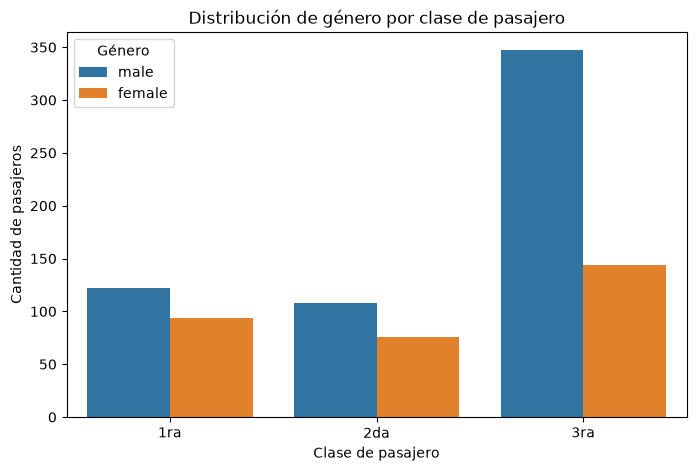

In [22]:
#Crea una gráfica que muestre la distribución de género dentro de cada clase de pasajero (Pclass).
import matplotlib.pyplot as plt
import seaborn as sns

# Etiquetas más descriptivas para las clases
df['Clase'] = df['Pclass'].map({
    1: '1ra',
    2: '2da',
    3: '3ra'
})

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Clase',
    hue='Sex',
    order=['1ra', '2da', '3ra']
)

plt.title('Distribución de género por clase de pasajero')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad de pasajeros')
plt.legend(title='Género')

plt.show()

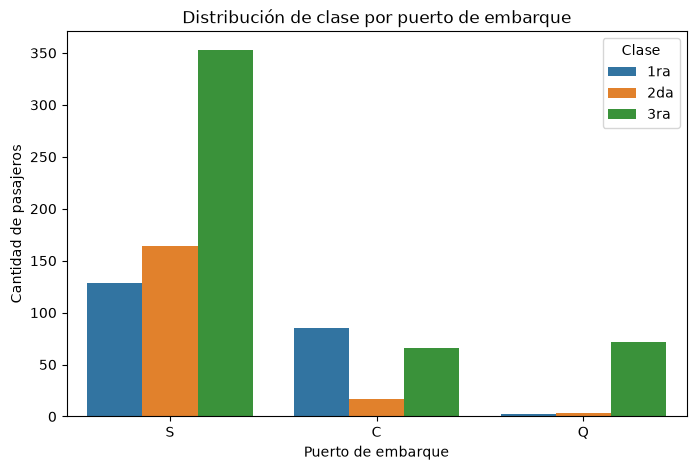

In [23]:
#Crea una gráfica que muestre la distribución de clase de pasajero por puerto de embarque (Embarked).
import matplotlib.pyplot as plt
import seaborn as sns

# Etiquetas para las clases
df['Clase'] = df['Pclass'].map({
    1: '1ra',
    2: '2da',
    3: '3ra'
})

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Embarked',
    hue='Clase',
    hue_order=['1ra', '2da', '3ra']
)

plt.title('Distribución de clase por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad de pasajeros')
plt.legend(title='Clase')

plt.show()

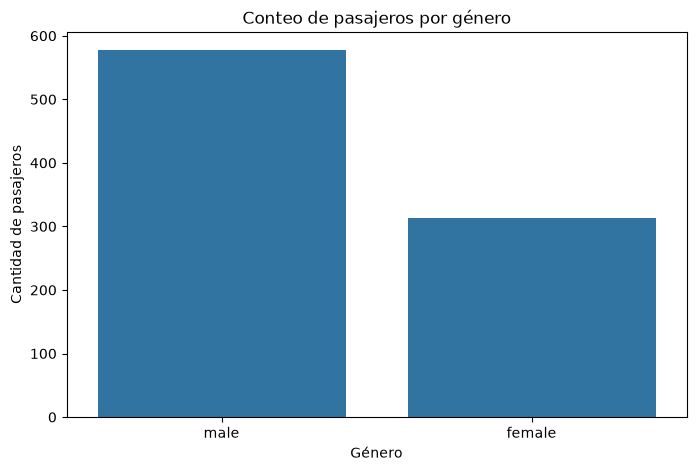

In [24]:
#Crea una gráfica que muestre el conteo de pasajeros por género (Sex).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Sex'
)

plt.title('Conteo de pasajeros por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de pasajeros')

plt.show()

In [25]:
#Encuentra y muestra los valores máximo y mínimo de la columna de edad.
print(df['Age'].agg(['min', 'max']))

min     0.42
max    80.00
Name: Age, dtype: float64


In [26]:
# Valor mínimo y máximo de la columna Age
edad_min = df['Age'].min()
edad_max = df['Age'].max()

print("Edad mínima:", edad_min)
print("Edad máxima:", edad_max)

Edad mínima: 0.42
Edad máxima: 80.0


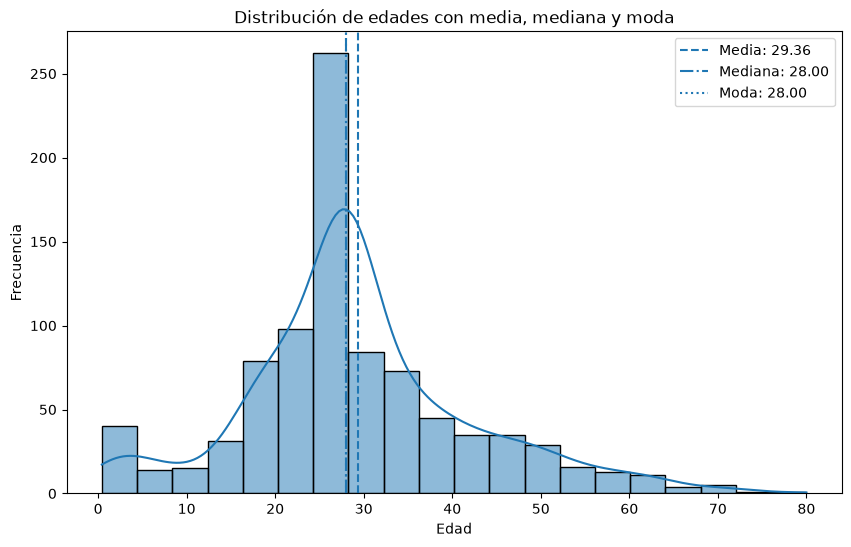

In [27]:
#Crea una gráfica que muestre la distribución de edades, incluyendo líneas verticales que indiquen la media, mediana y moda de las edades.
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular estadísticas
media = df['Age'].mean()
mediana = df['Age'].median()
moda = df['Age'].mode()[0]

# Crear gráfica
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)

# Líneas verticales
plt.axvline(media, linestyle='--', label=f'Media: {media:.2f}')
plt.axvline(mediana, linestyle='-.', label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, linestyle=':', label=f'Moda: {moda:.2f}')

plt.title('Distribución de edades con media, mediana y moda')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

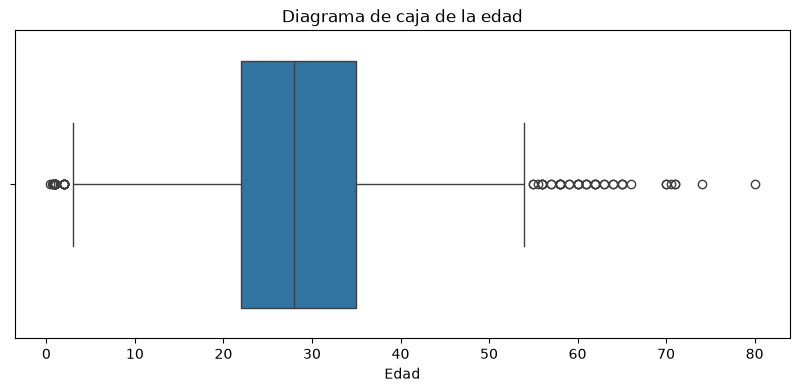

In [28]:
#Crea un diagrama de caja (boxplot) que muestre los outliers en la columna de edad.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Age'])

plt.title('Diagrama de caja de la edad')
plt.xlabel('Edad')

plt.show()

In [29]:
#Encuentra y muestra los valores máximo y mínimo de la columna de tarifa (Fare).
# Valor mínimo y máximo de la columna Fare
fare_min = df['Fare'].min()
fare_max = df['Fare'].max()

print("Tarifa mínima:", fare_min)
print("Tarifa máxima:", fare_max)

Tarifa mínima: 0.0
Tarifa máxima: 512.3292


In [30]:
print(df['Fare'].agg(['min', 'max']))

min      0.0000
max    512.3292
Name: Fare, dtype: float64


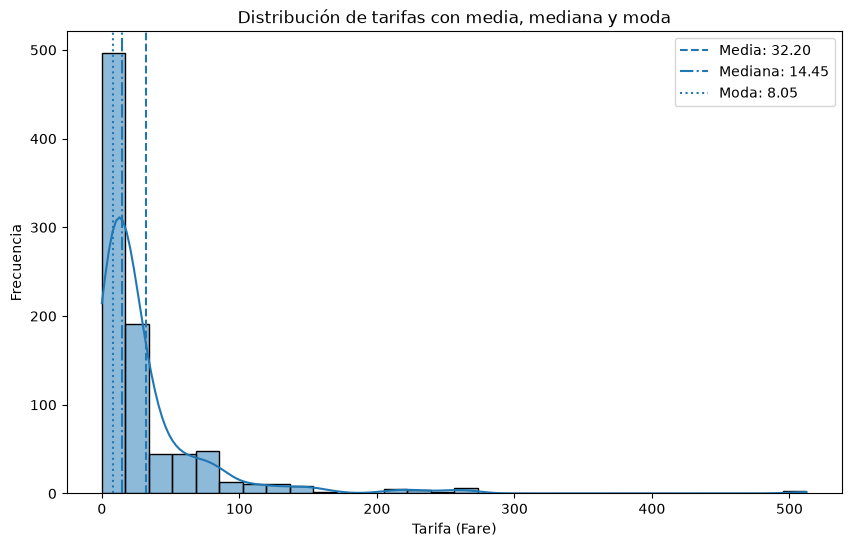

In [31]:
#Crea una gráfica que muestre la distribución de tarifas, incluyendo líneas verticales que indiquen la media, mediana y moda de las tarifas.
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular estadísticas
media = df['Fare'].mean()
mediana = df['Fare'].median()
moda = df['Fare'].mode()[0]

# Crear histograma
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], bins=30, kde=True)

# Agregar líneas verticales
plt.axvline(media, linestyle='--', label=f'Media: {media:.2f}')
plt.axvline(mediana, linestyle='-.', label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, linestyle=':', label=f'Moda: {moda:.2f}')

plt.title('Distribución de tarifas con media, mediana y moda')
plt.xlabel('Tarifa (Fare)')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

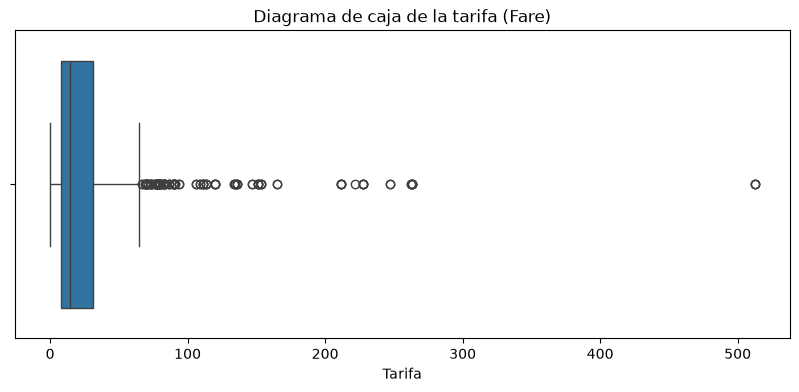

In [32]:
#Crea un diagrama de caja (boxplot) que muestre los outliers en la columna de tarifa (Fare).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Fare'])

plt.title('Diagrama de caja de la tarifa (Fare)')
plt.xlabel('Tarifa')

plt.show()

In [33]:
#Filtra y muestra los datos de los pasajeros que pagaron 0 en tarifa.
# Mostrar pasajeros con tarifa igual a 0
pasajeros_fare_0 = df[df['Fare'] == 0]

print(pasajeros_fare_0)

     Survived  Pclass   Sex   Age  SibSp  Parch  Fare Embarked     GrupoEdad  \
179         0       3  male  36.0      0      0   0.0        S        Adulto   
263         0       1  male  40.0      0      0   0.0        S        Adulto   
271         1       3  male  25.0      0      0   0.0        S  Joven Adulto   
277         0       2  male  28.0      0      0   0.0        S  Joven Adulto   
302         0       3  male  19.0      0      0   0.0        S  Joven Adulto   
413         0       2  male  28.0      0      0   0.0        S  Joven Adulto   
466         0       2  male  28.0      0      0   0.0        S  Joven Adulto   
481         0       2  male  28.0      0      0   0.0        S  Joven Adulto   
597         0       3  male  49.0      0      0   0.0        S        Adulto   
633         0       1  male  28.0      0      0   0.0        S  Joven Adulto   
674         0       2  male  28.0      0      0   0.0        S  Joven Adulto   
732         0       2  male  28.0      0

In [34]:
#cuantos son
print("Pasajeros con tarifa 0:", len(df[df['Fare'] == 0]))

Pasajeros con tarifa 0: 15


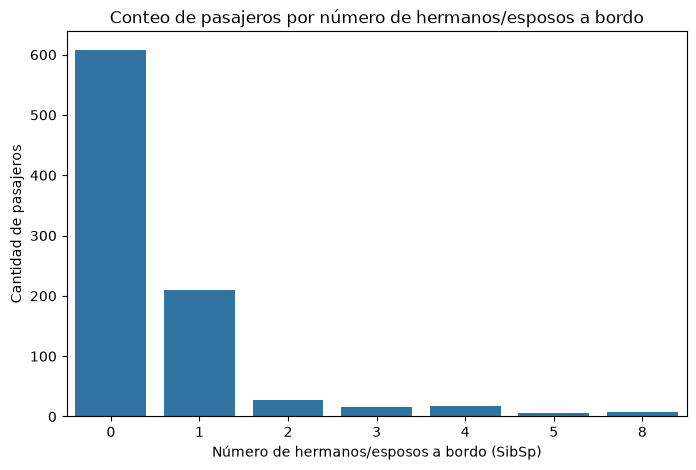

In [36]:
#Crea una gráfica que muestre el conteo de pasajeros por número de hermanos/esposos a bordo (SibSp).
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='SibSp'
)

plt.title('Conteo de pasajeros por número de hermanos/esposos a bordo')
plt.xlabel('Número de hermanos/esposos a bordo (SibSp)')
plt.ylabel('Cantidad de pasajeros')

plt.show()

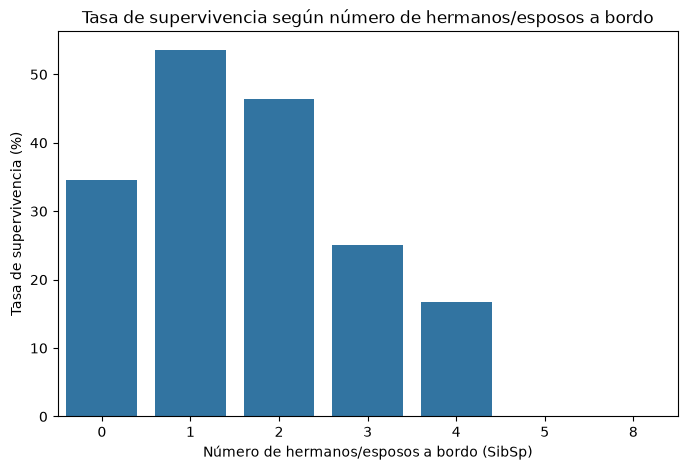

In [37]:
#Crea una gráfica que muestre la tasa de supervivencia basada en el número de hermanos/esposos a bordo (SibSp).
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular tasa de supervivencia por SibSp
survival_rate = df.groupby('SibSp')['Survived'].mean() * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    x=survival_rate.index,
    y=survival_rate.values
)

plt.title('Tasa de supervivencia según número de hermanos/esposos a bordo')
plt.xlabel('Número de hermanos/esposos a bordo (SibSp)')
plt.ylabel('Tasa de supervivencia (%)')

plt.show()


In [38]:
#Calcula y muestra el porcentaje de supervivencia para cada valor de SibSp.
# Calcular porcentaje de supervivencia por SibSp
porcentaje_supervivencia = df.groupby('SibSp')['Survived'].mean() * 100

print(porcentaje_supervivencia.round(2))


SibSp
0    34.54
1    53.59
2    46.43
3    25.00
4    16.67
5     0.00
8     0.00
Name: Survived, dtype: float64


In [39]:
#en forma de tabla
resultado = (
    df.groupby('SibSp')['Survived']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='Porcentaje_Supervivencia')
)

print(resultado)

   SibSp  Porcentaje_Supervivencia
0      0                     34.54
1      1                     53.59
2      2                     46.43
3      3                     25.00
4      4                     16.67
5      5                      0.00
6      8                      0.00


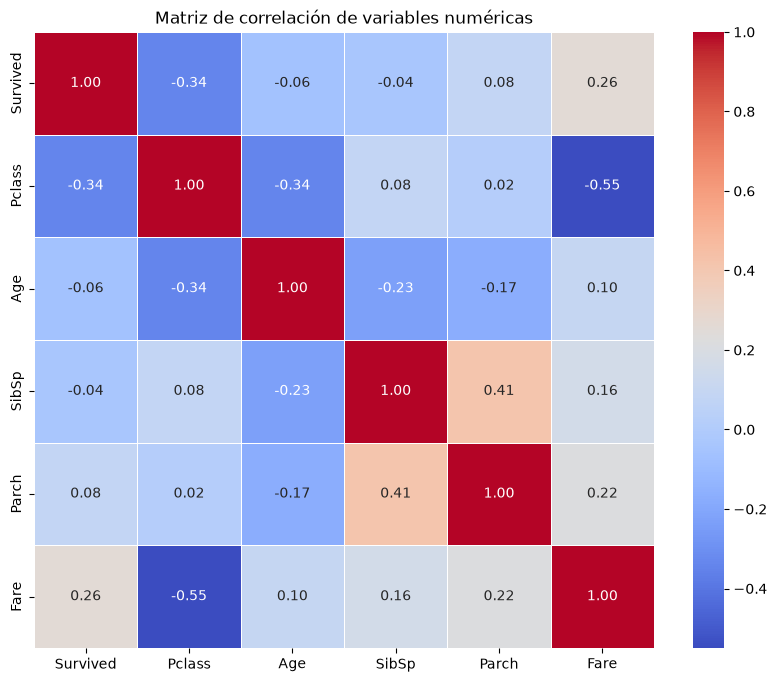

In [40]:
#Crea un mapa de calor (heatmap) que muestre la matriz de correlación de las características numéricas en el dataset.
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo columnas numéricas
df_numerico = df.select_dtypes(include=['number'])

# Calcular matriz de correlación
corr = df_numerico.corr()

# Crear mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriz de correlación de variables numéricas')
plt.show()